# Spam / Ham Email Classifier

A logistic regression pipeline that distinguishes spam from legitimate (ham) email with **93.8% training accuracy** and **91% test accuracy**.

The pipeline combines Term Frequency-Inverse Document Frequency-inspired word scoring scheme with feature-engineering (character count, exclamation frequency, capitalization ratio), and is validated with 10-fold cross-validation.

**Stack:** Python · scikit-learn · pandas · NumPy · seaborn

## Setup

In [1]:
import numpy as np
import pandas as pd
import re
import warnings
import os
from collections import Counter

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style='whitegrid', color_codes=True, font_scale=1.5)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

import joblib

warnings.filterwarnings('ignore')

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

## Helper Functions

In [2]:
def words_in_texts(words, texts):
    """
    Build a binary indicator matrix: entry [i, j] = 1 if words[j]
    appears anywhere in texts[i], 0 otherwise.
    """
    return np.array(
        [texts.str.contains(w, case=False, na=False).astype(int) for w in words]
    ).T

## Data

The dataset should be a collection of real-world emails labelled `1` (spam) or `0` (ham), shipped as a zip archive containing separate train and test CSVs.

Place `spam_ham_data.zip` in `data/raw/` and run this notebook from the **repo root** before executing cells below. Everything will be lowercased up front.

In [3]:
import zipfile

with zipfile.ZipFile('../data/raw/spam_ham_data.zip') as zf:
    with zf.open('train.csv') as f:
        raw = pd.read_csv(f)
    with zf.open('test.csv') as f:
        test_raw = pd.read_csv(f)

raw['email']      = raw['email'].str.lower().fillna('')
raw['subject']    = raw['subject'].fillna('')
test_raw['email'] = test_raw['email'].str.lower().fillna('')

print(f'Labelled examples : {len(raw):,}')
print(f'Spam rate         : {raw["spam"].mean():.1%}')
print(f'Unlabelled test   : {len(test_raw):,}')
raw.head(3)

Labelled examples : 8,348
Spam rate         : 25.6%
Unlabelled test   : 1,000


,id,subject,email,spam
0,0,Subject: A&L Daily to be auctioned in bankrupt...,url: http://boingboing.net/#85534171\n date: n...,0
1,1,"Subject: Wired: ""Stronger ties between ISPs an...",url: http://scriptingnews.userland.com/backiss...,0
2,2,Subject: It's just too small ...,<html>\n <head>\n </head>\n <body>\n <font siz...,1


In [4]:
train, val = train_test_split(raw, test_size=0.10, random_state=42)
train = train.reset_index(drop=True)
val   = val.reset_index(drop=True)

print(f'Train : {len(train):,}  |  Val : {len(val):,}')

Train : 7,513  |  Val : 835


## Exploratory Data Analysis

Before committing to any features to use, I checked which properties correlate with being labeled spam. The heatmap below measures linear correlation between four candidate features and the target.

A few things stand out: **exclamation mark count** is the strongest individual signal, and **character count** is a distant second. Word count and character count are highly correlated with each other (~0.95), so including both would add redundancy and overfitting. Thus, we only keep character count.

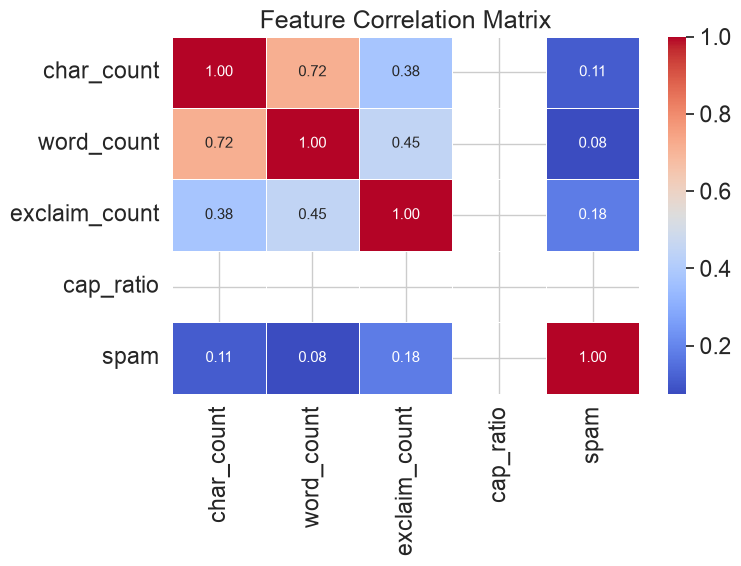

In [5]:
def add_numeric_features(df):
    d = df.copy()
    d['char_count']    = d['email'].str.len()
    d['word_count']    = d['email'].str.split().str.len()
    d['exclaim_count'] = d['email'].str.count('!')
    d['cap_ratio']     = d['email'].str.count(r'[A-Z]') / d['char_count'].replace(0, 1)
    return d

eda = add_numeric_features(raw)
corr_cols = ['char_count', 'word_count', 'exclaim_count', 'cap_ratio', 'spam']

plt.figure(figsize=(8, 6))
sns.heatmap(
    eda[corr_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    annot_kws={'size': 11}, linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/figures/feature_correlation.png', dpi=150)
plt.show()

## Feature Engineering

### Word features — TF-IDF-inspired scoring

We will score every word in the training corpus by how much more often it appears in spam versus ham, using Laplace smoothing to avoid division by zero:

$$\text{score}(w) = \frac{\text{count}_\text{spam}(w) + 1}{\text{count}_\text{ham}(w) + 1}$$

We then keep the top-800 words by this score as binary indicator features. 

This is a lighter alternative to a full TF-IDF that works well for short-vocabulary binary classification.

### Numeric features

We append four feature-engineered columns derived from the email body:
- **char_count** — total character length
- **word_count** — number of whitespace-separated tokens
- **exclaim_count** — number of `!` characters
- **caps_ratio** — fraction of characters that are uppercase

In [6]:
spam_text   = ' '.join(train.loc[train['spam'] == 1, 'email'])
ham_text    = ' '.join(train.loc[train['spam'] == 0, 'email'])
spam_counts = Counter(re.findall(r'[a-z]+', spam_text))
ham_counts  = Counter(re.findall(r'[a-z]+', ham_text))

word_scores = {
    w: (c + 1) / (ham_counts.get(w, 0) + 1)
    for w, c in spam_counts.items()
    if len(w) >= 3
}

TOP_K = 800
word_features = [
    w for w, _ in sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
]

print('Top 20 spam-indicative words:')
print(word_features[:20])

Top 20 spam-indicative words:
['iiq', 'cfont', 'ffont', 'ptsize', 'yni', 'insuranceiq', 'sansserif', 'milf', 'zvbnq', 'enenkio', 'udd', 'jeweldive', 'btamail', 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa', 'msonormal', 'xvcj', 'fromyou', 'nsi', 'insurancemail', 'dagga']


In [7]:
def numeric_features(emails):
    df = pd.DataFrame()
    df['char_count']    = emails.str.len()
    df['word_count']    = emails.str.split().str.len()
    df['exclaim_count'] = emails.str.count('!')
    df['caps_ratio']    = emails.str.count(r'[A-Z]') / df['char_count'].replace(0, 1)
    return df.to_numpy()


def build_features(df):
    """Combine word indicators and numeric features into a single matrix."""
    X_words = words_in_texts(word_features, df['email'])
    X_num   = numeric_features(df['email'])
    return np.hstack([X_words, X_num])


X_train = build_features(train)
y_train = train['spam'].to_numpy()

X_val = build_features(val)
y_val = val['spam'].to_numpy()

print(f'Feature matrix shape: {X_train.shape}')

Feature matrix shape: (7513, 804)


## Model Training

We will use logistic regression with the `liblinear` solver, which handles high-dimensional sparse feature matrices efficiently and supports L1 regularization, which is useful for zeroing out weak features.

In [8]:
clf = LogisticRegression(max_iter=2000, solver='liblinear')
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
val_acc   = clf.score(X_val,   y_val)

print(f'Training accuracy   : {train_acc:.4f}')
print(f'Validation accuracy : {val_acc:.4f}')

Training accuracy   : 0.9509
Validation accuracy : 0.9293


## Cross-Validation

10-fold CV on the full training set will give a more reliable accuracy estimate than a single hold-out split.

CV scores : [0.9481 0.9402 0.9468 0.9308 0.9587 0.9454 0.9348 0.9387 0.9467 0.9454]
Mean      : 0.9436
Std       : 0.0074


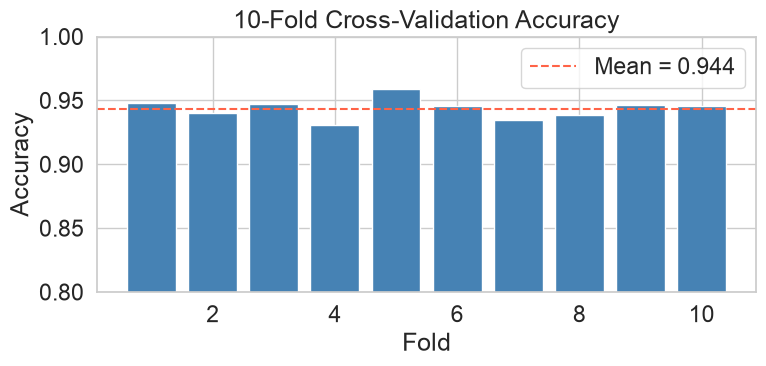

In [9]:
cv_scores = cross_val_score(clf, X_train, y_train, cv=10, scoring='accuracy')

print(f'CV scores : {np.round(cv_scores, 4)}')
print(f'Mean      : {cv_scores.mean():.4f}')
print(f'Std       : {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='tomato', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.title('10-Fold Cross-Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/cross_validation.png', dpi=150)
plt.show()

## Evaluation

### Confusion matrix

Spam filtering has error costs: a false positive (legitimate email flagged as spam) is more disruptive to a user than a false negative (spam that slips through).

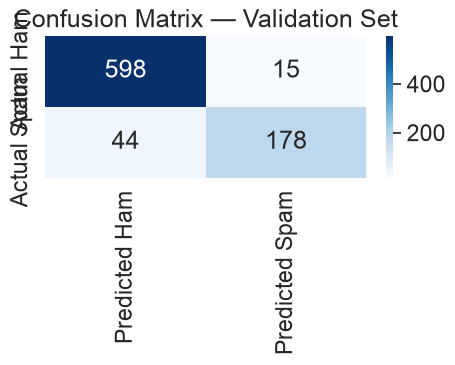

              precision    recall  f1-score   support

         Ham       0.93      0.98      0.95       613
        Spam       0.92      0.80      0.86       222

    accuracy                           0.93       835
   macro avg       0.93      0.89      0.91       835
weighted avg       0.93      0.93      0.93       835



In [10]:
val_preds = clf.predict(X_val)

cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Ham', 'Predicted Spam'],
    yticklabels=['Actual Ham', 'Actual Spam']
)
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_val, val_preds, target_names=['Ham', 'Spam']))

### ROC Curve


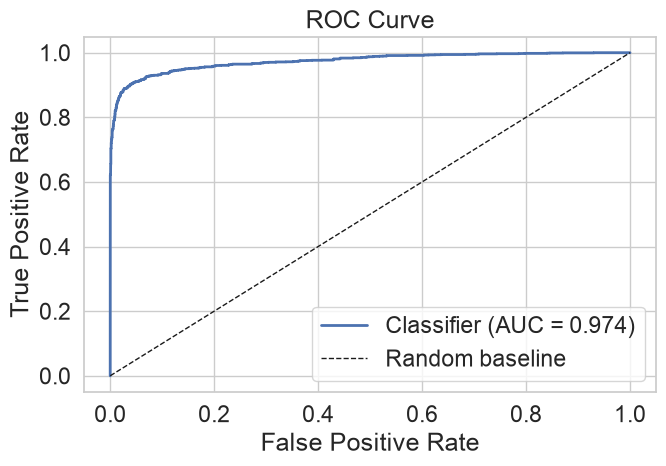

In [11]:
probs = clf.predict_proba(X_train)[:, 1]
fpr, tpr, _ = roc_curve(y_train, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'Classifier (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../results/figures/roc_curve.png', dpi=150)
plt.show()

## Feature Interpretability

A larger positive coefficient means the feature is a strong spam signal, while a more negative coefficient means the feature points toward ham.

The plots below show the 20 most influential features in each direction.

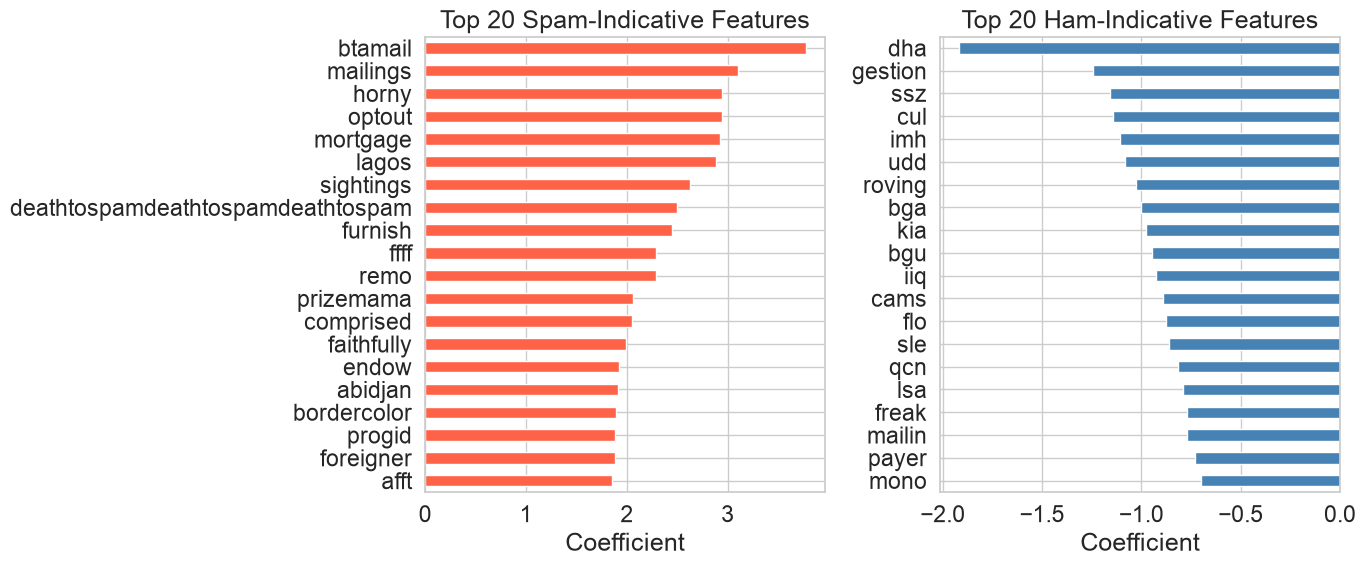

In [12]:
numeric_names  = ['char_count', 'word_count', 'exclaim_count', 'caps_ratio']
all_feat_names = word_features + numeric_names
coef_series    = pd.Series(clf.coef_[0], index=all_feat_names)

top_n    = 20
top_spam = coef_series.nlargest(top_n).sort_values()
top_ham  = coef_series.nsmallest(top_n).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_spam.plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title(f'Top {top_n} Spam-Indicative Features')
axes[0].set_xlabel('Coefficient')

top_ham.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title(f'Top {top_n} Ham-Indicative Features')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('../results/figures/feature_coefficients.png', dpi=150)
plt.show()

## Export Model

In [13]:
model_payload = {
    'classifier': clf,
    'word_features': word_features,
}
joblib.dump(model_payload, '../models/spam_classifier.joblib')
print('Model saved → models/spam_classifier.joblib')

Model saved → models/spam_classifier.joblib


## Generating Predictions

Apply the same feature pipeline to the held-out test set and export to CSV.

In [15]:
X_test     = build_features(test_raw)
test_preds = clf.predict(X_test)

output = pd.DataFrame({'Id': test_raw['id'], 'Class': test_preds})
output.to_csv('../results/spam_predictions.csv', index=False)

print(f'Model predicts that this amount of test emails are spam: {test_preds.mean():.1%}')
print('Saved → results/spam_predictions.csv')
output.head()

Model predicts that this amount of test emails are spam: 20.3%
Saved → results/spam_predictions.csv


,Id,Class
0,0,0
1,1,1
2,2,1
3,3,0
4,4,0
